# Chapter 12 — Strong scaling of a GaAs SCF

Companion notebook to Chapter 12. We plot the measured speedup of the
light GaAs SCF (`code/12-hpc/strong_scan.dat`, `-npool = cores`) against
ideal linear scaling, to see how quickly a small job saturates.
Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

d = Path('../code/12-hpc')
n, t = np.loadtxt(d/'strong_scan.dat', skiprows=1, unpack=True)
speedup = t[0] / t
eff = speedup / n
for c, w, s, e in zip(n, t, speedup, eff):
    print(f'{int(c):2d} cores: {w:4.1f} s  speedup {s:4.2f}x  efficiency {100*e:3.0f}%')

 1 cores:  8.0 s  speedup 1.00x  efficiency 100%
 2 cores:  5.7 s  speedup 1.41x  efficiency  71%
 4 cores:  3.7 s  speedup 2.19x  efficiency  55%
 8 cores:  2.9 s  speedup 2.78x  efficiency  35%
16 cores:  2.8 s  speedup 2.92x  efficiency  18%


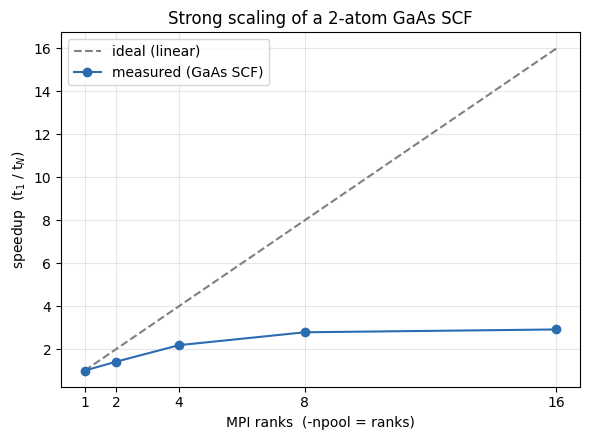

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(n, n, '--', color='gray', label='ideal (linear)')
ax.plot(n, speedup, 'o-', color='#2b6cb0', label='measured (GaAs SCF)')
ax.set_xlabel('MPI ranks  (-npool = ranks)')
ax.set_ylabel('speedup  (t$_1$ / t$_N$)')
ax.set_title('Strong scaling of a 2-atom GaAs SCF')
ax.set_xticks(n)
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(d.parent.parent/'static/img/12-scaling.png', dpi=120)
plt.show()

**What you see.** The measured curve tracks the ideal line for the first
few cores, then bends away and flattens: a 2-atom cell has too little work
to keep many cores busy, so parallel overhead wins. The practical takeaway
is to size the core count to the job — a tiny SCF wants a handful of cores,
while the phonon dispersions of Chapters 10–11 justified a whole node.